In [1]:
import pandas as pd
df = pd.read_csv("residential_input.csv")

df

,postcode,households,electricity_per_household_kwh
0,"1,098",2070,1800


In [2]:
households_real = df.loc[0,"households"]
electricity_per_household = df.loc[0,"electricity_per_household_kwh"]

print("Households:", households_real)
print("Electricity per household:", electricity_per_household)

Households: 2070
Electricity per household: 1800


In [3]:
households_simulated = 50

weight = households_real / households_simulated

print("Scaling factor:", weight)

Scaling factor: 41.4


In [4]:
from ramp import User, UseCase
import numpy as np

In [5]:
households = User(user_name="PC1098_households", num_users=households_simulated)

In [6]:
households.add_appliance(
    name="Fridge",
    number=1,
    power=80,
    num_windows=1,
    func_time=1440,
    func_cycle=1,
    window_1=[0,1440]
)

           user_name  num_users    name  number  power
0  PC1098_households         50  Fridge       1   80.0

In [7]:
households.add_appliance(
    name="Lighting",
    number=5,
    power=10,
    num_windows=2,
    func_time=180,
    func_cycle=1,
    window_1=[360,480],
    window_2=[1080,1380]
)

           user_name  num_users      name  number  power
0  PC1098_households         50  Lighting       5   10.0

In [8]:
households.add_appliance(
    name="Electronics",
    number=2,
    power=70,
    num_windows=2,
    func_time=240,
    func_cycle=1,
    window_1=[420,600],
    window_2=[1140,1380]
)

           user_name  num_users         name  number  power
0  PC1098_households         50  Electronics       2   70.0

In [9]:
households.add_appliance(
    name="Cooking",
    number=1,
    power=1800,
    num_windows=2,
    func_time=60,
    func_cycle=1,
    window_1=[420,510],
    window_2=[1020,1200]
)

           user_name  num_users     name  number   power
0  PC1098_households         50  Cooking       1  1800.0

In [10]:
households.add_appliance(
    name="WashingMachine",
    number=1,
    power=500,
    num_windows=1,
    func_time=60,
    func_cycle=1,
    window_1=[600,1260]
)

           user_name  num_users            name  number  power
0  PC1098_households         50  WashingMachine       1  500.0

In [11]:
households.add_appliance(
    name="BaseLoad",
    number=1,
    power=120,
    num_windows=1,
    func_time=1440,
    func_cycle=1,
    window_1=[0,1440]
)

           user_name  num_users      name  number  power
0  PC1098_households         50  BaseLoad       1  120.0

In [14]:
case = UseCase(users=[households])

In [15]:
case.initialize(num_days=366)

You will simulate 366 day(s) from 2026-03-11 00:00:00 until 2027-03-12 00:00:00


In [17]:
profiles = case.generate_daily_load_profiles(
    flat=True,
    verbose=False
)

In [18]:
profile = np.array(profiles)

profile_real = profile * weight
profile_kw = profile_real / 1000

In [19]:
annual_energy = profile_kw.sum()/60
daily_energy = annual_energy / 365

print("Peak load (kW):", profile_kw.max())
print("Annual energy (kWh):", annual_energy)
print("Average daily energy (kWh):", daily_energy)

Peak load (kW): 2560.5950921999997
Annual energy (kWh): 5705139.21162
Average daily energy (kWh): 15630.518388


In [20]:
output = pd.DataFrame({
    "minute": np.arange(len(profile_kw)),
    "load_kw": profile_kw
})

output.to_csv("PC1098_residential_load_year.csv", index=False)

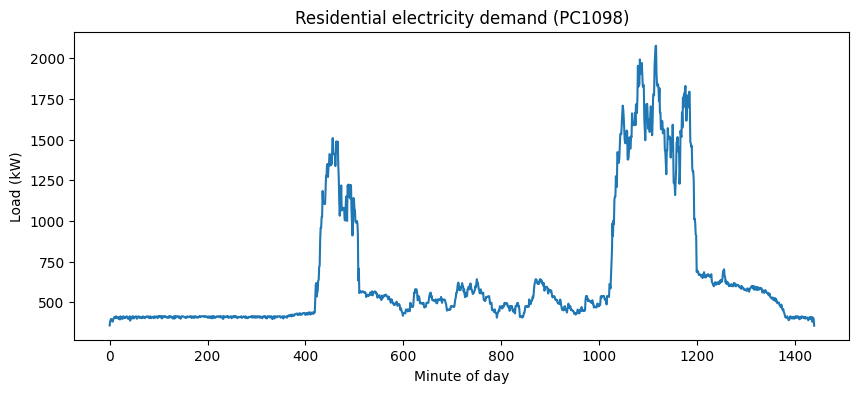

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(profile_kw[:1440])
plt.xlabel("Minute of day")
plt.ylabel("Load (kW)")
plt.title("Residential electricity demand (PC1098)")
plt.show()